In [1]:
# For Google Colab only!

!cat /proc/driver/nvidia/gpus/0000:00:04.0/information

Model: 		 Tesla T4
IRQ:   		 11
GPU UUID: 	 GPU-7dd33c12-a132-0418-061e-d936aba33246
Video BIOS: 	 90.04.a7.00.01
Bus Type: 	 PCI
DMA Size: 	 47 bits
DMA Mask: 	 0x7fffffffffff
Bus Location: 	 0000:00:04.0
Device Minor: 	 0
GPU Firmware: 	 580.82.07
GPU Excluded:	 No


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib import *
import seaborn as sns

In [3]:
import tensorflow as tf
from tensorflow import keras

In [4]:
print(tf.__version__)

2.19.0


In [5]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [6]:
np.random.seed()

In [22]:
from google.colab import files
uploaded = files.upload()

Saving USATECHIDXUSD_10 Mins_Ask_2025.01.01_2025.12.31.csv to USATECHIDXUSD_10 Mins_Ask_2025.01.01_2025.12.31.csv
Saving USATECHIDXUSD_10 Mins_Bid_2025.01.01_2025.12.31.csv to USATECHIDXUSD_10 Mins_Bid_2025.01.01_2025.12.31.csv


## Data
### Using US tech 100 indices as a target data for forecasting.
#### Time range - one year
#### Time interval - 10 mins


In [23]:
ls

 sample_data/
'USATECHIDXUSD_10 Mins_Ask_2025.01.01_2025.12.31.csv'
'USATECHIDXUSD_10 Mins_Bid_2025.01.01_2025.12.31.csv'


In [24]:
df_2025_Ask = pd.read_csv("USATECHIDXUSD_10 Mins_Ask_2025.01.01_2025.12.31.csv")
df_2025_Bid = pd.read_csv("USATECHIDXUSD_10 Mins_Bid_2025.01.01_2025.12.31.csv")

In [25]:
print(df_2025_Ask.head(3))
print(df_2025_Ask.tail(3))

            Time (EET)       Open       High        Low      Close  Volume 
0  2025.01.02 01:00:00  21073.681  21117.813  21051.611  21105.779  0.11745
1  2025.01.02 01:10:00  21105.224  21108.690  21090.857  21092.747  0.05913
2  2025.01.02 01:20:00  21092.669  21100.968  21084.201  21095.413  0.05949
                Time (EET)       Open       High        Low      Close  \
34352  2025.12.31 22:50:00  25276.725  25292.855  25240.354  25249.506   
34353  2025.12.31 23:00:00  25250.627  25271.344  25236.688  25242.964   
34354  2025.12.31 23:10:00  25242.910  25251.466  25242.329  25250.748   

       Volume   
34352  0.47919  
34353  0.09395  
34354  0.02085  


In [26]:
print(df_2025_Bid.head(3))
print(df_2025_Bid.tail(3))

            Time (EET)       Open       High        Low      Close  Volume 
0  2025.01.02 01:00:00  21070.242  21114.409  21048.187  21102.210   0.1305
1  2025.01.02 01:10:00  21101.754  21105.186  21087.354  21089.221   0.0657
2  2025.01.02 01:20:00  21089.110  21097.519  21080.809  21091.986   0.0661
                Time (EET)       Open       High        Low      Close  \
34352  2025.12.31 22:50:00  25275.531  25291.650  25239.248  25248.323   
34353  2025.12.31 23:00:00  25249.488  25270.429  25235.461  25241.836   
34354  2025.12.31 23:10:00  25241.716  25250.327  25241.102  25249.532   

       Volume   
34352  0.35820  
34353  0.06943  
34354  0.01582  


In [27]:
data = df_2025_Bid.merge(df_2025_Ask, left_on='Time (EET)', right_on='Time (EET)', how='outer')
data

,Time (EET),Open_x,High_x,Low_x,Close_x,Volume _x,Open_y,High_y,Low_y,Close_y,Volume _y
0,2025.01.02 01:00:00,21070.242,21114.409,21048.187,21102.210,0.13050,21073.681,21117.813,21051.611,21105.779,0.11745
1,2025.01.02 01:10:00,21101.754,21105.186,21087.354,21089.221,0.06570,21105.224,21108.690,21090.857,21092.747,0.05913
2,2025.01.02 01:20:00,21089.110,21097.519,21080.809,21091.986,0.06610,21092.669,21100.968,21084.201,21095.413,0.05949
3,2025.01.02 01:30:00,21092.153,21098.953,21044.720,21062.687,0.10190,21095.635,21102.357,21048.290,21066.091,0.09171
4,2025.01.02 01:40:00,21062.498,21065.385,21038.365,21046.599,0.09710,21065.913,21068.836,21041.836,21049.813,0.08739
...,...,...,...,...,...,...,...,...,...,...,...
34350,2025.12.31 22:30:00,25272.238,25307.191,25265.221,25291.165,0.28795,25273.344,25308.440,25266.459,25292.282,0.38307
34351,2025.12.31 22:40:00,25291.785,25302.845,25274.770,25275.358,0.27333,25292.711,25303.995,25275.703,25276.519,0.36444
34352,2025.12.31 22:50:00,25275.531,25291.650,25239.248,25248.323,0.35820,25276.725,25292.855,25240.354,25249.506,0.47919
34353,2025.12.31 23:00:00,25249.488,25270.429,25235.461,25241.836,0.06943,25250.627,25271.344,25236.688,25242.964,0.09395


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34355 entries, 0 to 34354
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time (EET)  34355 non-null  object 
 1   Open_x      34355 non-null  float64
 2   High_x      34355 non-null  float64
 3   Low_x       34355 non-null  float64
 4   Close_x     34355 non-null  float64
 5   Volume _x   34355 non-null  float64
 6   Open_y      34355 non-null  float64
 7   High_y      34355 non-null  float64
 8   Low_y       34355 non-null  float64
 9   Close_y     34355 non-null  float64
 10  Volume _y   34355 non-null  float64
dtypes: float64(10), object(1)
memory usage: 2.9+ MB


In [29]:
data.columns = ['Local time', 'Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
                   'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask']

In [30]:
data.head(3)

,Local time,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask
0,2025.01.02 01:00:00,21070.242,21114.409,21048.187,21102.210,0.1305,21073.681,21117.813,21051.611,21105.779,0.11745
1,2025.01.02 01:10:00,21101.754,21105.186,21087.354,21089.221,0.0657,21105.224,21108.690,21090.857,21092.747,0.05913
2,2025.01.02 01:20:00,21089.110,21097.519,21080.809,21091.986,0.0661,21092.669,21100.968,21084.201,21095.413,0.05949


In [31]:
data["Volume_Delta"] = data["Volume_Ask"] - data["Volume_Bid"]
data["Volume_Delta_abs"] = (data["Volume_Ask"] - data["Volume_Bid"]).abs()

In [32]:
data["Open_Delta"] = data["Open_Ask"] - data["Open_Bid"]
data["High_Delta"] = data["High_Ask"] - data["High_Bid"]
data["Low_Delta"] = data["Low_Ask"] - data["Low_Bid"]
data["Close_Delta"] = data["Close_Ask"] - data["Close_Bid"]

In [33]:
data.describe()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta
count,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000,34355.000000
mean,22542.971959,22556.969095,22528.601908,22543.103425,0.177095,22545.253765,22559.225517,22530.862865,22545.371164,0.205042,0.027948,0.050850,2.281806,2.256422,2.260958,2.267739
std,2164.432195,2160.718121,2167.796003,2164.293277,0.145194,2163.809305,2160.084099,2167.168340,2163.659905,0.161907,0.071368,0.057347,1.131416,1.107713,1.114151,1.119424
min,16391.198000,16439.389000,16324.253000,16391.210000,0.000000,16394.690000,16442.614000,16328.757000,16394.681000,0.000000,-0.780480,0.000000,0.001000,0.001000,0.003000,0.001000
25%,21165.514500,21182.115000,21150.397500,21165.830500,0.066720,21168.358000,21184.336000,21153.557000,21168.553000,0.078840,0.000710,0.012350,1.189000,1.183000,1.183000,1.192000
50%,22653.931000,22660.164000,22647.065000,22654.298000,0.128460,22657.081000,22663.290000,22650.169000,22657.180000,0.148080,0.022540,0.031060,1.520000,1.504000,1.506000,1.515000
75%,24574.506000,24588.649000,24560.442000,24574.170500,0.269925,24575.652000,24590.225000,24561.813500,24575.649500,0.314400,0.059310,0.072915,3.450000,3.438000,3.438000,3.450000
max,26253.338000,26257.272000,26231.772000,26253.131000,1.274710,26254.466000,26258.455000,26232.981000,26254.303000,0.912390,0.240630,0.780480,16.432000,15.906000,19.112000,18.939000


In [34]:
data.shape

(34355, 17)

In [35]:
import datetime

In [36]:
data["Local_time_T"] = pd.to_datetime(data['Local time'], utc=True)

In [37]:
data = data.drop(['Local time'], axis=1)

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34355 entries, 0 to 34354
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   Open_Bid          34355 non-null  float64            
 1   High_Bid          34355 non-null  float64            
 2   Low_Bid           34355 non-null  float64            
 3   Close_Bid         34355 non-null  float64            
 4   Volume_Bid        34355 non-null  float64            
 5   Open_Ask          34355 non-null  float64            
 6   High_Ask          34355 non-null  float64            
 7   Low_Ask           34355 non-null  float64            
 8   Close_Ask         34355 non-null  float64            
 9   Volume_Ask        34355 non-null  float64            
 10  Volume_Delta      34355 non-null  float64            
 11  Volume_Delta_abs  34355 non-null  float64            
 12  Open_Delta        34355 non-null  float64            
 13  H

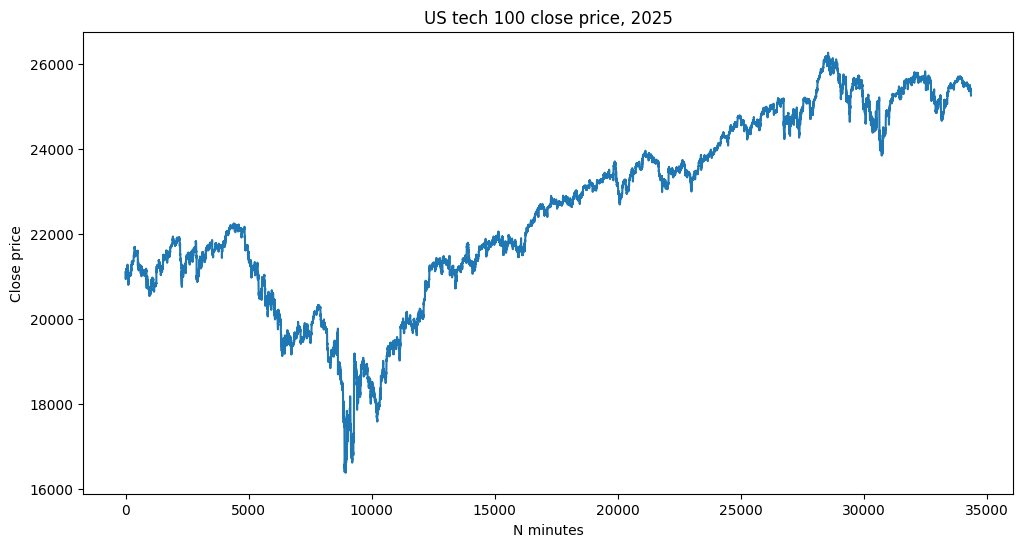

In [39]:
plt.figure(figsize=(12,6))
plt.plot(data['Close_Bid'])
plt.title('US tech 100 close price, 2025')
plt.xlabel('N minutes')
plt.ylabel('Close price')
plt.show()

<Figure size 900x400 with 0 Axes>

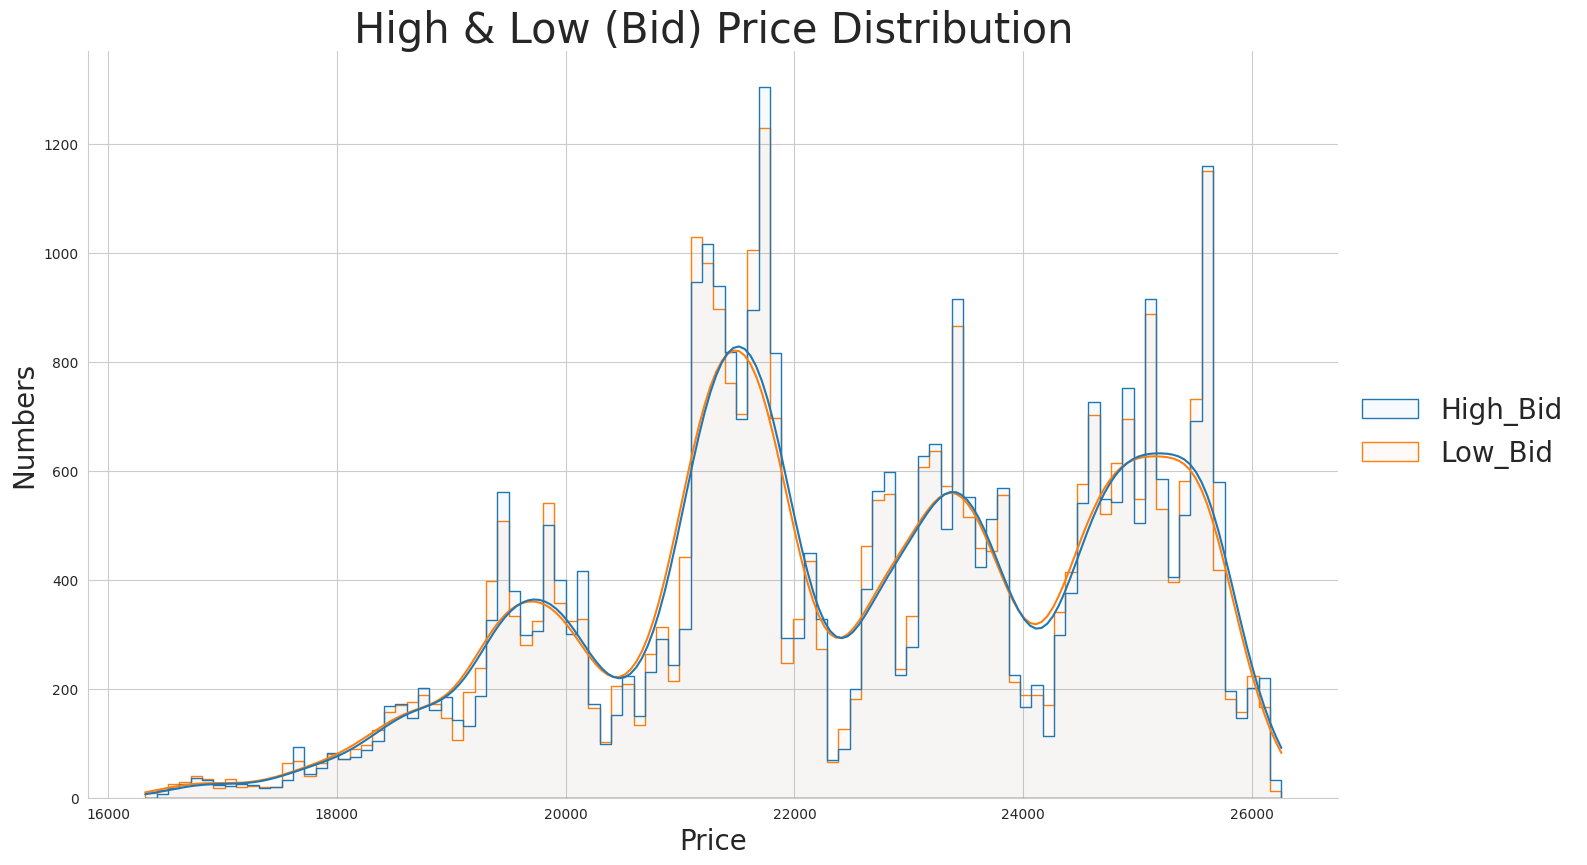

In [40]:
fig = plt.figure(figsize=(9, 4))
plt.rc('axes', titlesize= 30 )
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 20.0})

sns.displot(
            data[['High_Bid', 'Low_Bid']],
            height=8,
            aspect=1.7,
            #hue="species",
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,

)

plt.title('High & Low (Bid) Price Distribution')
plt.xlabel('Price', size= 20)
#plt.ylabel('count (%)')
plt.ylabel('Numbers', size= 20)
plt.show();

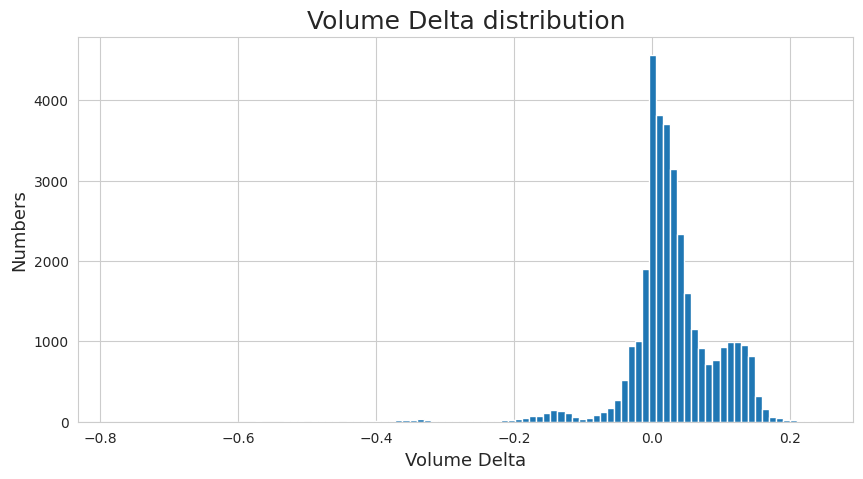

In [41]:
plt.figure(num=1,figsize=(10,5))
plt.hist(data['Volume_Delta'],bins=100)
plt.title('Volume Delta distribution',size=18)
plt.ylabel('Numbers',size=13)
plt.xlabel('Volume Delta',size=13)
plt.show();

In [ ]:
# Distribution has mostly positive values
# So Volume_Ask is usually greater than Volume_Bid,
# This corresponds to the upward trend in the year 2025

In [42]:
data['Local_time_T_shipt_1_Down'] = data['Local_time_T'].shift(1)

In [43]:
data["Local_time_T_Delta"] = data["Local_time_T"] - data["Local_time_T_shipt_1_Down"]

In [44]:
data.head(-5)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta
0,21070.242,21114.409,21048.187,21102.210,0.13050,21073.681,21117.813,21051.611,21105.779,0.11745,-0.01305,0.01305,3.439,3.404,3.424,3.569,2025-01-02 01:00:00+00:00,NaT,NaT
1,21101.754,21105.186,21087.354,21089.221,0.06570,21105.224,21108.690,21090.857,21092.747,0.05913,-0.00657,0.00657,3.470,3.504,3.503,3.526,2025-01-02 01:10:00+00:00,2025-01-02 01:00:00+00:00,0 days 00:10:00
2,21089.110,21097.519,21080.809,21091.986,0.06610,21092.669,21100.968,21084.201,21095.413,0.05949,-0.00661,0.00661,3.559,3.449,3.392,3.427,2025-01-02 01:20:00+00:00,2025-01-02 01:10:00+00:00,0 days 00:10:00
3,21092.153,21098.953,21044.720,21062.687,0.10190,21095.635,21102.357,21048.290,21066.091,0.09171,-0.01019,0.01019,3.482,3.404,3.570,3.404,2025-01-02 01:30:00+00:00,2025-01-02 01:20:00+00:00,0 days 00:10:00
4,21062.498,21065.385,21038.365,21046.599,0.09710,21065.913,21068.836,21041.836,21049.813,0.08739,-0.00971,0.00971,3.415,3.451,3.471,3.214,2025-01-02 01:40:00+00:00,2025-01-02 01:30:00+00:00,0 days 00:10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34345,25338.588,25351.649,25336.785,25339.682,0.23439,25339.481,25352.744,25337.841,25340.821,0.29892,0.06453,0.06453,0.893,1.095,1.056,1.139,2025-12-31 21:40:00+00:00,2025-12-31 21:30:00+00:00,0 days 00:10:00
34346,25339.062,25342.619,25326.942,25331.161,0.21879,25340.234,25343.501,25328.147,25332.311,0.29172,0.07293,0.07293,1.172,0.882,1.205,1.150,2025-12-31 21:50:00+00:00,2025-12-31 21:40:00+00:00,0 days 00:10:00
34347,25331.411,25334.686,25291.867,25297.048,0.28851,25332.605,25335.601,25292.771,25298.220,0.37788,0.08937,0.08937,1.194,0.915,0.904,1.172,2025-12-31 22:00:00+00:00,2025-12-31 21:50:00+00:00,0 days 00:10:00
34348,25296.689,25306.309,25278.745,25299.734,0.29979,25297.806,25307.290,25279.671,25300.884,0.39552,0.09573,0.09573,1.117,0.981,0.926,1.150,2025-12-31 22:10:00+00:00,2025-12-31 22:00:00+00:00,0 days 00:10:00


In [ ]:
data['Local_time_T_Delta'].iloc[0] = "2 days 01:01:00"
data['Local_time_T_Delta'].iloc[0]

/tmp/ipykernel_12859/1040467289.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['Local_time_T_Delta'].iloc[0] = "2 days 01:01:00"
/tmp/ipykernel_12859/1040467289.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy o

Timedelta('2 days 01:01:00')

In [47]:
new_day = data[['Local_time_T_Delta']][data["Local_time_T_Delta"] > '0 days 00:09:00']
new_day['Local_time_T_Delta'].value_counts(sort=False)

,count
Local_time_T_Delta,
0 days 00:10:00,34097
0 days 01:50:00,197
2 days 01:50:00,45
0 days 08:40:00,1
0 days 05:10:00,6
2 days 00:50:00,2
2 days 02:50:00,2
3 days 01:50:00,1
2 days 05:10:00,1


In [48]:
new_week = data[['Local_time_T_Delta']][data['Local_time_T_Delta'] > '1 days 00:00:00']
new_week["Local_time_T_Delta"].value_counts(sort=False)

,count
Local_time_T_Delta,
2 days 01:50:00,45
2 days 00:50:00,2
2 days 02:50:00,2
3 days 01:50:00,1
2 days 05:10:00,1
2 days 04:50:00,1
1 days 04:50:00,1


In [49]:
data['New_day'] = 0
data['New_week'] = 0

In [50]:
data.loc[data["Local_time_T_Delta"] > '0 days 00:09:00', 'New_day'] = 1

In [51]:
data[data["New_day"] == 1]

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,...,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta,New_day,New_week
1,21101.754,21105.186,21087.354,21089.221,0.06570,21105.224,21108.690,21090.857,21092.747,0.05913,...,0.00657,3.470,3.504,3.503,3.526,2025-01-02 01:10:00+00:00,2025-01-02 01:00:00+00:00,0 days 00:10:00,1,0
2,21089.110,21097.519,21080.809,21091.986,0.06610,21092.669,21100.968,21084.201,21095.413,0.05949,...,0.00661,3.559,3.449,3.392,3.427,2025-01-02 01:20:00+00:00,2025-01-02 01:10:00+00:00,0 days 00:10:00,1,0
3,21092.153,21098.953,21044.720,21062.687,0.10190,21095.635,21102.357,21048.290,21066.091,0.09171,...,0.01019,3.482,3.404,3.570,3.404,2025-01-02 01:30:00+00:00,2025-01-02 01:20:00+00:00,0 days 00:10:00,1,0
4,21062.498,21065.385,21038.365,21046.599,0.09710,21065.913,21068.836,21041.836,21049.813,0.08739,...,0.00971,3.415,3.451,3.471,3.214,2025-01-02 01:40:00+00:00,2025-01-02 01:30:00+00:00,0 days 00:10:00,1,0
5,21046.899,21063.131,21045.431,21060.720,0.06550,21050.135,21066.669,21048.892,21064.203,0.05895,...,0.00655,3.236,3.538,3.461,3.483,2025-01-02 01:50:00+00:00,2025-01-02 01:40:00+00:00,0 days 00:10:00,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34350,25272.238,25307.191,25265.221,25291.165,0.28795,25273.344,25308.440,25266.459,25292.282,0.38307,...,0.09512,1.106,1.249,1.238,1.117,2025-12-31 22:30:00+00:00,2025-12-31 22:20:00+00:00,0 days 00:10:00,1,0
34351,25291.785,25302.845,25274.770,25275.358,0.27333,25292.711,25303.995,25275.703,25276.519,0.36444,...,0.09111,0.926,1.150,0.933,1.161,2025-12-31 22:40:00+00:00,2025-12-31 22:30:00+00:00,0 days 00:10:00,1,0
34352,25275.531,25291.650,25239.248,25248.323,0.35820,25276.725,25292.855,25240.354,25249.506,0.47919,...,0.12099,1.194,1.205,1.106,1.183,2025-12-31 22:50:00+00:00,2025-12-31 22:40:00+00:00,0 days 00:10:00,1,0
34353,25249.488,25270.429,25235.461,25241.836,0.06943,25250.627,25271.344,25236.688,25242.964,0.09395,...,0.02452,1.139,0.915,1.227,1.128,2025-12-31 23:00:00+00:00,2025-12-31 22:50:00+00:00,0 days 00:10:00,1,0


In [52]:
data.loc[data["Local_time_T_Delta"] > '1 days 00:00:00', 'New_week'] = 1

In [53]:
data[data["New_week"] ==1].head(20)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,...,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,Local_time_T,Local_time_T_shipt_1_Down,Local_time_T_Delta,New_day,New_week
268,21339.209,21345.543,21315.032,21322.532,0.10850,21342.669,21349.036,21318.301,21326.079,0.09765,...,0.01085,3.460,3.493,3.269,3.547,2025-01-06 01:00:00+00:00,2025-01-03 23:10:00+00:00,2 days 01:50:00,1,1
897,20835.142,20840.654,20776.210,20788.119,0.14740,20838.657,20844.103,20779.703,20791.558,0.13266,...,0.01474,3.515,3.449,3.493,3.439,2025-01-13 01:00:00+00:00,2025-01-10 23:10:00+00:00,2 days 01:50:00,1,1
1567,21442.697,21465.587,21389.686,21408.719,0.24940,21446.157,21468.881,21393.081,21412.179,0.22455,...,0.02485,3.460,3.294,3.395,3.460,2025-01-20 01:00:00+00:00,2025-01-17 23:10:00+00:00,2 days 01:50:00,1,1
2217,21629.810,21629.810,21523.065,21557.119,0.22190,21633.325,21633.325,21526.535,21560.525,0.19974,...,0.02216,3.515,3.515,3.470,3.406,2025-01-27 01:00:00+00:00,2025-01-24 23:10:00+00:00,2 days 01:50:00,1,1
2887,21025.775,21025.775,20837.498,20965.999,0.30350,21029.258,21029.258,20840.958,20969.246,0.27321,...,0.03029,3.483,3.483,3.460,3.247,2025-02-03 01:00:00+00:00,2025-01-31 23:10:00+00:00,2 days 01:50:00,1,1
3557,21342.142,21458.219,21324.821,21457.898,0.19870,21345.636,21461.668,21328.380,21461.292,0.17883,...,0.01987,3.494,3.449,3.559,3.394,2025-02-10 01:00:00+00:00,2025-02-07 23:10:00+00:00,2 days 01:50:00,1,1
4227,22156.808,22156.808,22129.264,22130.843,0.08118,22160.191,22160.191,22132.746,22134.358,0.08136,...,0.00018,3.383,3.383,3.482,3.515,2025-02-17 01:00:00+00:00,2025-02-14 23:10:00+00:00,2 days 01:50:00,1,1
4877,21638.076,21673.698,21610.553,21671.989,0.20619,21641.557,21677.091,21614.069,21675.235,0.20742,...,0.00123,3.481,3.393,3.516,3.246,2025-02-24 01:00:00+00:00,2025-02-21 23:10:00+00:00,2 days 01:50:00,1,1
5547,20951.010,20988.332,20918.120,20987.609,0.15809,20954.568,20991.669,20921.635,20990.981,0.15822,...,0.00013,3.558,3.337,3.515,3.372,2025-03-03 01:00:00+00:00,2025-02-28 23:10:00+00:00,2 days 01:50:00,1,1
6217,20074.310,20075.264,20007.075,20018.864,0.10728,20077.836,20078.768,20010.579,20022.358,0.08046,...,0.02682,3.526,3.504,3.504,3.494,2025-03-10 00:00:00+00:00,2025-03-07 23:10:00+00:00,2 days 00:50:00,1,1


In [54]:
data2 = data.drop(['Local_time_T', 'Local_time_T_shipt_1_Down', 'Local_time_T_Delta'], axis=1)

In [55]:
data2.head(3)

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week
0,21070.242,21114.409,21048.187,21102.210,0.1305,21073.681,21117.813,21051.611,21105.779,0.11745,-0.01305,0.01305,3.439,3.404,3.424,3.569,0,0
1,21101.754,21105.186,21087.354,21089.221,0.0657,21105.224,21108.690,21090.857,21092.747,0.05913,-0.00657,0.00657,3.470,3.504,3.503,3.526,1,0
2,21089.110,21097.519,21080.809,21091.986,0.0661,21092.669,21100.968,21084.201,21095.413,0.05949,-0.00661,0.00661,3.559,3.449,3.392,3.427,1,0


In [56]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34355 entries, 0 to 34354
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          34355 non-null  float64
 1   High_Bid          34355 non-null  float64
 2   Low_Bid           34355 non-null  float64
 3   Close_Bid         34355 non-null  float64
 4   Volume_Bid        34355 non-null  float64
 5   Open_Ask          34355 non-null  float64
 6   High_Ask          34355 non-null  float64
 7   Low_Ask           34355 non-null  float64
 8   Close_Ask         34355 non-null  float64
 9   Volume_Ask        34355 non-null  float64
 10  Volume_Delta      34355 non-null  float64
 11  Volume_Delta_abs  34355 non-null  float64
 12  Open_Delta        34355 non-null  float64
 13  High_Delta        34355 non-null  float64
 14  Low_Delta         34355 non-null  float64
 15  Close_Delta       34355 non-null  float64
 16  New_day           34355 non-null  int64 

In [57]:
data = []

In [ ]:
# Y_close_4h (4-hour-ahead close price) will be created after normalisation
# No intermediate helper columns needed
data2.head(2)

In [ ]:
data2.shape

In [60]:
max_price = (data2['High_Ask']).max()
max_price

26258.455

In [61]:
min_price = data2['Low_Bid'].min()
min_price

16324.253

In [62]:
max_volume = max(max(data2['Volume_Bid']), max(data2['Volume_Ask']))
max_volume

1.27471

In [63]:
max_Delta = max(max(data2['Open_Delta']), max(data2['High_Delta']), max(data2['Low_Delta']), max(data2['Close_Delta']))
max_Delta

19.11200000000099

In [64]:
max_Delta = round(max_Delta, 3)
max_Delta

19.112

In [65]:
min_Delta = min(min(data2['Open_Delta']), min(data2['High_Delta']), min(data2['Low_Delta']), min(data2['Close_Delta']))
min_Delta

0.000999999996565748

In [66]:
min_Delta = round(min_Delta, 3)
min_Delta

0.001

In [67]:
max_volume_Delta = data2['Volume_Delta'].max()
max_volume_Delta

0.24063

In [68]:
max_volume_Delta = round(max_volume_Delta, 5)
max_volume_Delta

0.24063

In [69]:
min_volume_Delta = data2['Volume_Delta'].min()
min_volume_Delta

-0.7804800000000001

In [70]:
min_volume_Delta = round(min_volume_Delta, 5)
min_volume_Delta

-0.78048

In [71]:
max_volume_Delta_abs = data2['Volume_Delta_abs'].max()
max_volume_Delta_abs

0.7804800000000001

In [72]:
max_volume_Delta_abs = round(max_volume_Delta_abs, 5)
max_volume_Delta_abs

0.78048

In [73]:
min_volume_Delta_abs = data2['Volume_Delta_abs'].min()
min_volume_Delta_abs

0.0

In [ ]:
# Normalise prices (min-max, divisor = 26 000)

data2['Open_Bid']  = data2['Open_Bid']  / 26000
data2['High_Bid']  = data2['High_Bid']  / 26000
data2['Low_Bid']   = data2['Low_Bid']   / 26000
data2['Close_Bid'] = data2['Close_Bid'] / 26000

data2['Open_Ask']  = data2['Open_Ask']  / 26000
data2['High_Ask']  = data2['High_Ask']  / 26000
data2['Low_Ask']   = data2['Low_Ask']   / 26000
data2['Close_Ask'] = data2['Close_Ask'] / 26000

In [75]:
data2['Volume_Ask']  = data2['Volume_Ask'] / max_volume
data2['Volume_Bid']  = data2['Volume_Bid'] / max_volume

In [76]:
data2['Volume_Delta'] = ( data2['Volume_Delta'] - min_volume_Delta ) / (max_volume_Delta-min_volume_Delta)

In [77]:
data2['Volume_Delta_abs']  = data2['Volume_Delta_abs'] / max_volume_Delta_abs

In [78]:
data2['Open_Delta']  = ( data2['Open_Delta']  - min_Delta ) / (max_Delta-min_Delta)
data2['High_Delta']  = ( data2['High_Delta']  - min_Delta ) / (max_Delta-min_Delta)
data2['Low_Delta']   = ( data2['Low_Delta']   - min_Delta ) / (max_Delta-min_Delta)
data2['Close_Delta'] = ( data2['Close_Delta'] - min_Delta ) / (max_Delta-min_Delta)

In [79]:
data2.head()

,Open_Bid,High_Bid,Low_Bid,Close_Bid,Volume_Bid,Open_Ask,High_Ask,Low_Ask,Close_Ask,Volume_Ask,Volume_Delta,Volume_Delta_abs,Open_Delta,High_Delta,Low_Delta,Close_Delta,New_day,New_week,Y_High_Bid,Y_Low_Ask
0,0.810394,0.812093,0.809546,0.811623,0.102376,0.810526,0.812224,0.809677,0.811761,0.092139,0.751564,0.016720,0.820104,0.821935,0.820888,0.813301,0,0,0.812093,0.809677
1,0.811606,0.811738,0.811052,0.811124,0.051541,0.811739,0.811873,0.811187,0.811260,0.046387,0.757911,0.008418,0.818482,0.816702,0.816755,0.815551,1,0,0.811738,0.811187
2,0.811120,0.811443,0.810800,0.811230,0.051855,0.811257,0.811576,0.810931,0.811362,0.046669,0.757871,0.008469,0.813824,0.819580,0.822563,0.820732,1,0,0.811443,0.810931
3,0.811237,0.811498,0.809412,0.810103,0.079940,0.811371,0.811629,0.809550,0.810234,0.071946,0.754365,0.013056,0.817854,0.821935,0.813249,0.821935,1,0,0.811498,0.809550
4,0.810096,0.810207,0.809168,0.809485,0.076174,0.810227,0.810340,0.809301,0.809608,0.068557,0.754835,0.012441,0.821359,0.819476,0.818429,0.831877,1,0,0.810207,0.809301


In [80]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34355 entries, 0 to 34354
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          34355 non-null  float64
 1   High_Bid          34355 non-null  float64
 2   Low_Bid           34355 non-null  float64
 3   Close_Bid         34355 non-null  float64
 4   Volume_Bid        34355 non-null  float64
 5   Open_Ask          34355 non-null  float64
 6   High_Ask          34355 non-null  float64
 7   Low_Ask           34355 non-null  float64
 8   Close_Ask         34355 non-null  float64
 9   Volume_Ask        34355 non-null  float64
 10  Volume_Delta      34355 non-null  float64
 11  Volume_Delta_abs  34355 non-null  float64
 12  Open_Delta        34355 non-null  float64
 13  High_Delta        34355 non-null  float64
 14  Low_Delta         34355 non-null  float64
 15  Close_Delta       34355 non-null  float64
 16  New_day           34355 non-null  int64 

In [ ]:
columns_float = [
    'Open_Bid', 'High_Bid', 'Low_Bid', 'Close_Bid', 'Volume_Bid',
    'Open_Ask', 'High_Ask', 'Low_Ask', 'Close_Ask', 'Volume_Ask',
    'Volume_Delta', 'Volume_Delta_abs',
    'Open_Delta', 'High_Delta', 'Low_Delta', 'Close_Delta'
]
columns_integer = ['New_day', 'New_week']

In [82]:
for column in columns_float:
  data2[column] = pd.to_numeric(data2[column], downcast = 'float')

for column in columns_integer:
  data2[column] = pd.to_numeric(data2[column], downcast = 'integer')

data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34355 entries, 0 to 34354
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          34355 non-null  float32
 1   High_Bid          34355 non-null  float32
 2   Low_Bid           34355 non-null  float32
 3   Close_Bid         34355 non-null  float32
 4   Volume_Bid        34355 non-null  float32
 5   Open_Ask          34355 non-null  float32
 6   High_Ask          34355 non-null  float32
 7   Low_Ask           34355 non-null  float32
 8   Close_Ask         34355 non-null  float32
 9   Volume_Ask        34355 non-null  float32
 10  Volume_Delta      34355 non-null  float32
 11  Volume_Delta_abs  34355 non-null  float32
 12  Open_Delta        34355 non-null  float32
 13  High_Delta        34355 non-null  float32
 14  Low_Delta         34355 non-null  float32
 15  Close_Delta       34355 non-null  float32
 16  New_day           34355 non-null  int8  

In [83]:
data2.shape

(34355, 20)

<Figure size 1200x500 with 0 Axes>

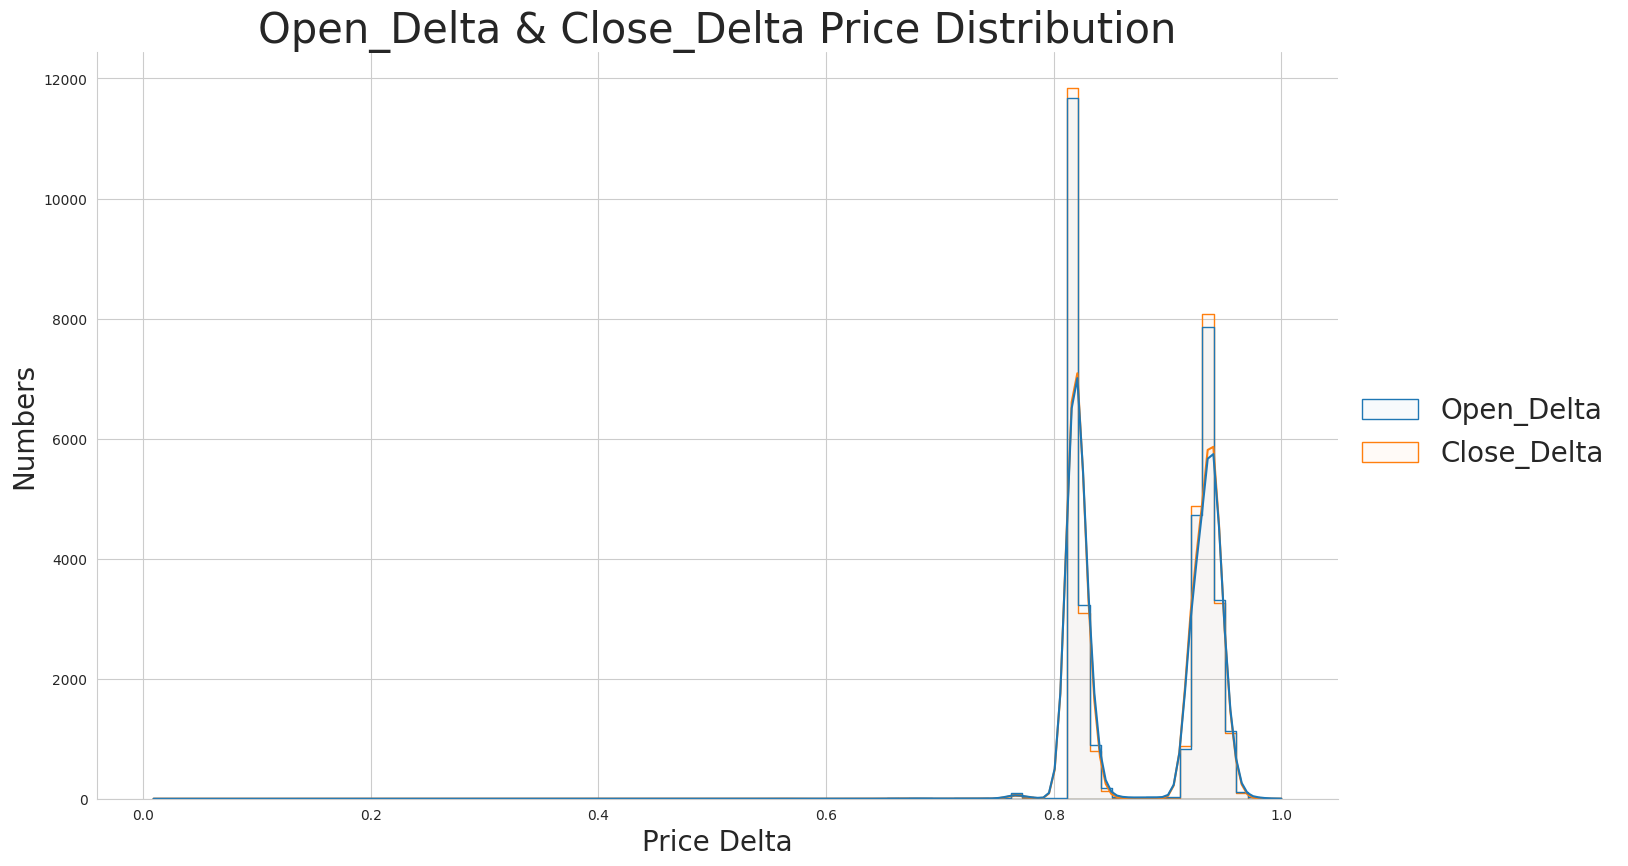

In [84]:
fig = plt.figure(figsize=(12, 5))
plt.rc('axes', titlesize= 30 )
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 20.0})

sns.displot(
            data2[['Open_Delta', 'Close_Delta']],
            height=8,
            aspect=1.7,
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,

)

plt.title('Open_Delta & Close_Delta Price Distribution')
plt.xlabel('Price Delta', size= 20)
plt.ylabel('Numbers', size= 20)
plt.show();

In [85]:
n = data2.shape[0]
n

34355

In [86]:
p = data2.shape[1]
p

20

In [ ]:
# ── Regression target: Close_Bid 4 hours ahead ──────────────────────────
# 4 hours = 24 bars × 10 min
# Created from already-normalised Close_Bid, so target lives in same [0,1] scale.
# Denormalise for USD price: value × 26 000
data2['Y_close_4h'] = data2['Close_Bid'].shift(-24)

# Drop the 24 tail rows that have NaN targets
data2 = data2.dropna(subset=['Y_close_4h']).reset_index(drop=True)
print(f'Dataset shape after 4h-target creation: {data2.shape}')

In [ ]:
# Quick visual: first 500 rows — current close vs 4h-ahead close
plt.figure(figsize=(13, 4))
plt.plot(data2['Close_Bid'].values[:500] * 26000,  label='Close_Bid (now)',      alpha=0.9)
plt.plot(data2['Y_close_4h'].values[:500] * 26000, label='Close_Bid (4h ahead)', alpha=0.8, linestyle='--')
plt.title('Current close vs 4-hour-ahead close (first 500 rows)')
plt.xlabel('Row index'); plt.ylabel('Price (USD)')
plt.legend(); plt.tight_layout(); plt.show()

In [104]:
data2.shape

(34331, 19)

In [ ]:
data_ay = data2[['Y_close_4h']]

In [106]:
data_ay.shape

(34331, 1)

In [ ]:
data_ax = data2.drop(['Y_close_4h'], axis=1)

In [108]:
data_ax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34331 entries, 0 to 34330
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open_Bid          34331 non-null  float32
 1   High_Bid          34331 non-null  float32
 2   Low_Bid           34331 non-null  float32
 3   Close_Bid         34331 non-null  float32
 4   Volume_Bid        34331 non-null  float32
 5   Open_Ask          34331 non-null  float32
 6   High_Ask          34331 non-null  float32
 7   Low_Ask           34331 non-null  float32
 8   Close_Ask         34331 non-null  float32
 9   Volume_Ask        34331 non-null  float32
 10  Volume_Delta      34331 non-null  float32
 11  Volume_Delta_abs  34331 non-null  float32
 12  Open_Delta        34331 non-null  float32
 13  High_Delta        34331 non-null  float32
 14  Low_Delta         34331 non-null  float32
 15  Close_Delta       34331 non-null  float32
 16  New_day           34331 non-null  int8  

In [109]:
data_ax.shape

(34331, 18)

In [110]:
data_a = np.array(data_ax)

with np.printoptions(precision=4):
    print("data_a:")
    print(data_a[:2,:])
    print('\n')
    print(data_a[-2:,:])

print("numpy size: = ", data_a.shape)
print("type: ", data_a.dtype)


data_a:
[[0.8104 0.8121 0.8095 0.8116 0.1024 0.8105 0.8122 0.8097 0.8118 0.0921
  0.7516 0.0167 0.8201 0.8219 0.8209 0.8133 0.     0.    ]
 [0.8116 0.8117 0.8111 0.8111 0.0515 0.8117 0.8119 0.8112 0.8113 0.0464
  0.7579 0.0084 0.8185 0.8167 0.8168 0.8156 1.     0.    ]]


[[0.9769 0.977  0.9756 0.9756 0.1708 0.977  0.977  0.9756 0.9757 0.2273
  0.8348 0.0922 0.9382 0.9416 0.9504 0.9358 1.     0.    ]
 [0.9757 0.9764 0.9755 0.9763 0.1723 0.9757 0.9765 0.9755 0.9763 0.2265
  0.8319 0.0884 0.9358 0.9422 0.9376 0.9399 1.     0.    ]]
numpy size: =  (34331, 18)
type:  float32


In [111]:
data_y = np.array(data_ay)

print("data_a:")
print(data_y[:3,:])
print('\n')
print(data_y[-3:,:])

print("numpy size: = ", data_y.shape)
print("type: ", data_y.dtype)

data_a:
[[1]
 [1]
 [1]]


[[0]
 [0]
 [0]]
numpy size: =  (34331, 1)
type:  int64


In [112]:
len(data_a)

34331

In [ ]:
from tqdm import tqdm

In [113]:
n_small = len(data_y)
n_small

34331

In [114]:
n_small = len(data_y)  # use full dataset

N=50               # sliding window depth

L=n_small-N        # number of sliding window slices
t=data_a.shape[1]  # features number
print('Size of a three-dimensional inputs tensor: ',L,N,t)


Size of a three-dimensional inputs tensor:  25800 50 18


In [115]:
data_b = np.zeros( (L, N, t), dtype= 'float32' )

In [ ]:
Y = np.zeros((L, 1), dtype='float32')  # regression target: normalised Close_Bid 4h ahead

In [118]:
# fill the imputs 3D tansor (data_b)
# and the array of answers Y
from tqdm.notebook import tqdm

print('L = n_small - N = ', n_small-N, L)
for k in tqdm(range(L)):
    data_b[k, :, :] = data_a[k:k+N, :]

    Y[k,0] = data_y[k+N-1,0]   # Trend-Flat signal

print(k)                       # index value (for control)

print('data_b:', '\n', data_b)
print("Numpy size:        ", data_b.shape, '\n')

print( Y[:5,:])
print( Y[-10:,:])
print(      "Numpy size:         ", Y.shape)

L = n_small - N =  25800 25800


  0%|          | 0/25800 [00:00<?, ?it/s]

25799
data_b: 
 [[[0.8103939  0.81209266 0.80954564 ... 0.81330127 0.         0.        ]
  [0.81160593 0.8117379  0.8110521  ... 0.8155513  1.         0.        ]
  [0.8111196  0.81144303 0.8108004  ... 0.8207315  1.         0.        ]
  ...
  [0.8145495  0.81499994 0.81436276 ... 0.83077806 1.         0.        ]
  [0.8147405  0.8150572  0.81440204 ... 0.8138768  1.         0.        ]
  [0.81469905 0.8147111  0.8140675  ... 0.817278   1.         0.        ]]

 [[0.81160593 0.8117379  0.8110521  ... 0.8155513  1.         0.        ]
  [0.8111196  0.81144303 0.8108004  ... 0.8207315  1.         0.        ]
  [0.8112367  0.81149817 0.8094123  ... 0.821935   1.         0.        ]
  ...
  [0.8147405  0.8150572  0.81440204 ... 0.8138768  1.         0.        ]
  [0.81469905 0.8147111  0.8140675  ... 0.817278   1.         0.        ]
  [0.8143251  0.81448966 0.8141281  ... 0.8296269  1.         0.        ]]

 [[0.8111196  0.81144303 0.8108004  ... 0.8207315  1.         0.        ]
  [0.8

In [ ]:
# Up/Down target: 1 if next bar's Close_Bid > current bar's Close_Bid
# data_ax column order: Open_Bid(0), High_Bid(1), Low_Bid(2), Close_Bid(3), ...
close_bid_seq = data_b[:, -1, 3]  # last timestep Close_Bid of each window
Y_updown = np.zeros((L, 1), dtype='float32')
Y_updown[:-1, 0] = (close_bid_seq[1:] > close_bid_seq[:-1]).astype('float32')
Y_updown[-1, 0] = 0  # no next bar for last sample

vals, cnts = np.unique(Y_updown, return_counts=True)
print('Up/Down distribution:', dict(zip(vals.astype(int), cnts)))

In [119]:
data_ax = []
data_ay = []
data_a = []
data_y = []

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
X_train, X_test, y_train, y_test = train_test_split(data_b, Y, test_size=0.1, shuffle = False, stratify = None, random_state=101)

In [122]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(23220, 50, 18)
(23220, 1)
(2580, 50, 18)
(2580, 1)


In [123]:
from sklearn.utils.class_weight import compute_class_weight

# Callback

In [ ]:
# Train/test split for Model 3 (Up/Down direction classification)
X_train_ud, X_test_ud, y_train_ud, y_test_ud = train_test_split(
    data_b, Y_updown, test_size=0.1, shuffle=False, random_state=101
)
from sklearn.utils.class_weight import compute_class_weight
class_weights_ud = compute_class_weight(
    'balanced', classes=np.unique(y_train_ud.ravel()), y=y_train_ud.ravel()
)
class_weight_ud_dict = {i: w for i, w in enumerate(class_weights_ud)}
print('Up/Down class weights:', class_weight_ud_dict)

## Model 1: Simple RNN — Regression (Predict Close Price 4 Hours Ahead)

In [ ]:
es1 = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)
mc1 = ModelCheckpoint('best_simple_rnn_2025.keras', monitor='val_loss',
                       mode='min', verbose=1, save_best_only=True)

model_rnn = keras.Sequential([
    keras.Input(shape=(50, 18)),
    keras.layers.SimpleRNN(64, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.SimpleRNN(32),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)          # linear output for regression
])

model_rnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='huber',
    metrics=['mae']
)
model_rnn.summary()

In [ ]:
history_rnn = model_rnn.fit(
    X_train, y_train,
    batch_size=64, epochs=50,
    validation_split=0.1, shuffle=True, verbose=1,
    callbacks=[es1, mc1]
)

In [ ]:
model_1    = keras.models.load_model('best_simple_rnn_2025.keras')
score_rnn  = model_1.evaluate(X_test, y_test, verbose=0)
rnn_loss, rnn_mae = score_rnn
rnn_mae_usd = rnn_mae * 26000
print(f'Simple RNN  |  Huber loss: {rnn_loss:.6f}  |  MAE: {rnn_mae:.6f}  ({rnn_mae_usd:.2f} USD)')

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_rnn.history['loss'],     label='train')
axes[0].plot(history_rnn.history['val_loss'], label='val')
axes[0].set_title('Simple RNN — Huber Loss'); axes[0].legend()
axes[1].plot(history_rnn.history['mae'],      label='train')
axes[1].plot(history_rnn.history['val_mae'],  label='val')
axes[1].set_title('Simple RNN — MAE'); axes[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
# ── Actual vs Predicted price (next 4 hours) ────────────────────────
N_PLOT = 300
y_pred_rnn_norm = model_1.predict(X_test[:N_PLOT], verbose=0).ravel()
y_true_norm     = y_test[:N_PLOT].ravel()

y_pred_rnn_usd  = y_pred_rnn_norm * 26000
y_true_usd      = y_true_norm     * 26000

mae_rnn  = np.abs(y_pred_rnn_usd - y_true_usd).mean()
rmse_rnn = np.sqrt(((y_pred_rnn_usd - y_true_usd)**2).mean())
print(f'Simple RNN  |  MAE = ${mae_rnn:.2f}  |  RMSE = ${rmse_rnn:.2f}')

plt.figure(figsize=(14, 5))
plt.plot(y_true_usd,     label='Actual Close 4h ahead',    alpha=0.85)
plt.plot(y_pred_rnn_usd, label='Predicted Close 4h ahead', alpha=0.85, linestyle='--')
plt.title('Simple RNN — Actual vs Predicted Close Price (Next 4 Hours)')
plt.xlabel('Test sample index'); plt.ylabel('Price (USD)')
plt.legend(); plt.tight_layout(); plt.show()

# Scatter: predicted vs actual
plt.figure(figsize=(5, 5))
plt.scatter(y_true_usd, y_pred_rnn_usd, alpha=0.3, s=8)
mn, mx = y_true_usd.min(), y_true_usd.max()
plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect prediction')
plt.xlabel('Actual (USD)'); plt.ylabel('Predicted (USD)')
plt.title('Simple RNN — Scatter'); plt.legend(); plt.tight_layout(); plt.show()

## Model 2: CNN — Regression (Predict Close Price 4 Hours Ahead)

In [ ]:
es2 = EarlyStopping(monitor="val_loss", mode="min", patience=10, verbose=1)
mc2 = ModelCheckpoint("best_cnn_2025.keras", monitor="val_loss",
                       mode="min", verbose=1, save_best_only=True)

inp2 = keras.Input(shape=(50, 18))
# Block 1
x2 = keras.layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(inp2)
x2 = keras.layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x2)
x2 = keras.layers.BatchNormalization()(x2)
x2 = keras.layers.MaxPooling1D(pool_size=2)(x2)       # 50 -> 25
x2 = keras.layers.Dropout(0.2)(x2)
# Block 2
x2 = keras.layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x2)
x2 = keras.layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x2)
x2 = keras.layers.BatchNormalization()(x2)
x2 = keras.layers.MaxPooling1D(pool_size=2)(x2)       # 25 -> 12
x2 = keras.layers.Dropout(0.2)(x2)
# Block 3
x2 = keras.layers.Conv1D(256, kernel_size=3, padding="same", activation="relu")(x2)
x2 = keras.layers.BatchNormalization()(x2)
x2 = keras.layers.GlobalAveragePooling1D()(x2)
# Head
x2 = keras.layers.Dense(128, activation="relu")(x2)
x2 = keras.layers.Dropout(0.3)(x2)
x2 = keras.layers.Dense(32,  activation="relu")(x2)
out2 = keras.layers.Dense(1)(x2)                      # linear for regression

model_cnn = keras.Model(inp2, out2)
model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="huber",
    metrics=["mae"]
)
model_cnn.summary()

In [ ]:
history_cnn = model_cnn.fit(
    X_train, y_train,
    batch_size=64, epochs=50,
    validation_split=0.1, shuffle=True, verbose=1,
    callbacks=[es2, mc2]
)

In [ ]:
model_2    = keras.models.load_model("best_cnn_2025.keras")
score_cnn  = model_2.evaluate(X_test, y_test, verbose=0)
cnn_loss, cnn_mae = score_cnn
cnn_mae_usd = cnn_mae * 26000
print(f"CNN  |  Huber loss: {cnn_loss:.6f}  |  MAE: {cnn_mae:.6f}  ({cnn_mae_usd:.2f} USD)")

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_cnn.history["loss"],     label="train")
axes[0].plot(history_cnn.history["val_loss"], label="val")
axes[0].set_title("CNN — Huber Loss"); axes[0].legend()
axes[1].plot(history_cnn.history["mae"],      label="train")
axes[1].plot(history_cnn.history["val_mae"],  label="val")
axes[1].set_title("CNN — MAE"); axes[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
# Actual vs Predicted price (next 4 hours)
N_PLOT = 300
y_pred_cnn_norm = model_2.predict(X_test[:N_PLOT], verbose=0).ravel()
y_pred_cnn_usd  = y_pred_cnn_norm * 26000

mae_cnn  = np.abs(y_pred_cnn_usd - y_true_usd).mean()
rmse_cnn = np.sqrt(((y_pred_cnn_usd - y_true_usd)**2).mean())
print(f"CNN  |  MAE = ${mae_cnn:.2f}  |  RMSE = ${rmse_cnn:.2f}")

plt.figure(figsize=(14, 5))
plt.plot(y_true_usd,     label="Actual Close 4h ahead",    alpha=0.85)
plt.plot(y_pred_cnn_usd, label="Predicted Close 4h ahead", alpha=0.85, linestyle="--")
plt.title("CNN — Actual vs Predicted Close Price (Next 4 Hours)")
plt.xlabel("Test sample index"); plt.ylabel("Price (USD)")
plt.legend(); plt.tight_layout(); plt.show()

# Scatter
plt.figure(figsize=(5, 5))
plt.scatter(y_true_usd, y_pred_cnn_usd, alpha=0.3, s=8)
mn, mx = y_true_usd.min(), y_true_usd.max()
plt.plot([mn, mx], [mn, mx], "r--", label="Perfect prediction")
plt.xlabel("Actual (USD)"); plt.ylabel("Predicted (USD)")
plt.title("CNN — Scatter"); plt.legend(); plt.tight_layout(); plt.show()

## Model 3: BiLSTM + GRU Ensemble — Up/Down Direction Classification

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

es3 = EarlyStopping(monitor='val_auc', patience=20,
                    restore_best_weights=True, mode='max', verbose=1)
lr3 = ReduceLROnPlateau(monitor='val_auc', factor=0.5,
                        patience=8, min_lr=1e-6, mode='max', verbose=1)
mc3 = ModelCheckpoint('best_bilstm_gru_2025.keras', monitor='val_auc',
                       mode='max', verbose=1, save_best_only=True)

inp3 = keras.Input(shape=(50, 18), name='shared_input')

# ── BiLSTM Branch ──────────────────────────────────────────────────────
b = keras.layers.Bidirectional(keras.layers.LSTM(128, return_sequences=True))(inp3)
b = keras.layers.Dropout(0.3)(b)
b = keras.layers.Bidirectional(keras.layers.LSTM(64,  return_sequences=False))(b)
b = keras.layers.Dropout(0.2)(b)

# ── GRU Branch ─────────────────────────────────────────────────────────
g = keras.layers.GRU(128, return_sequences=True)(inp3)
g = keras.layers.Dropout(0.3)(g)
g = keras.layers.GRU(64,  return_sequences=False)(g)
g = keras.layers.Dropout(0.2)(g)

# ── Merge + Classification Head ────────────────────────────────────────
merged = keras.layers.Concatenate()([b, g])   # (batch, 256)
x3     = keras.layers.Dense(64, activation='relu')(merged)
x3     = keras.layers.BatchNormalization()(x3)
x3     = keras.layers.Dropout(0.3)(x3)
out3   = keras.layers.Dense(1, activation='sigmoid', name='direction')(x3)

model_updown = keras.Model(inputs=inp3, outputs=out3, name='BiLSTM_GRU_Ensemble')
model_updown.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
model_updown.summary()

In [ ]:
history_updown = model_updown.fit(
    X_train_ud, y_train_ud,
    validation_split=0.1,
    epochs=120,
    batch_size=64,
    shuffle=True,
    verbose=1,
    callbacks=[es3, lr3, mc3],
    class_weight=class_weight_ud_dict
)

In [ ]:
model_3      = keras.models.load_model('best_bilstm_gru_2025.keras')
score_updown = model_3.evaluate(X_test_ud, y_test_ud, verbose=0)
ud_loss, ud_acc, ud_auc, ud_prec, ud_rec = score_updown
print(f'BiLSTM+GRU  |  Loss: {ud_loss:.4f}  |  Acc: {ud_acc:.4f}'
      f'  |  AUC: {ud_auc:.4f}  |  Prec: {ud_prec:.4f}  |  Rec: {ud_rec:.4f}')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_updown.history['loss'],     label='train')
axes[0].plot(history_updown.history['val_loss'], label='val')
axes[0].set_title('BiLSTM+GRU — Loss'); axes[0].legend()

axes[1].plot(history_updown.history['accuracy'],     label='train')
axes[1].plot(history_updown.history['val_accuracy'], label='val')
axes[1].set_title('BiLSTM+GRU — Accuracy'); axes[1].legend()

axes[2].plot(history_updown.history['auc'],     label='train')
axes[2].plot(history_updown.history['val_auc'], label='val')
axes[2].set_title('BiLSTM+GRU — AUC'); axes[2].legend()

plt.tight_layout(); plt.show()

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score
)
import itertools

y_pred_ud_prob = model_3.predict(X_test_ud, verbose=0).ravel()
y_true_ud      = y_test_ud.ravel().astype(int)

# ── Threshold tuning: maximise macro-F1 ────────────────────────────────
best_t, best_f1 = 0.5, 0.0
for t in np.arange(0.30, 0.71, 0.01):
    f1 = f1_score(y_true_ud, (y_pred_ud_prob >= t).astype(int), average='macro')
    if f1 > best_f1:
        best_f1, best_t = f1, t
print(f'Best threshold: {best_t:.2f}  (macro-F1 = {best_f1:.4f})')

y_pred_ud = (y_pred_ud_prob >= best_t).astype(int)

print(f'\n=== BiLSTM+GRU — Classification Report (threshold = {best_t:.2f}) ===')
print(classification_report(y_true_ud, y_pred_ud, target_names=['Down (0)', 'Up (1)']))
print(f'ROC-AUC : {roc_auc_score(y_true_ud, y_pred_ud_prob):.4f}')

# ── Confusion matrix ────────────────────────────────────────────────────
cm = confusion_matrix(y_true_ud, y_pred_ud)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Down', 'Up']); ax.set_yticklabels(['Down', 'Up'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('BiLSTM+GRU — Confusion Matrix')
for ii, jj in itertools.product(range(2), range(2)):
    ax.text(jj, ii, cm[ii, jj], ha='center', va='center',
            color='white' if cm[ii, jj] > cm.max() / 2 else 'black')
plt.tight_layout(); plt.show()

In [ ]:
# ── Compare predicted direction with actual price change (first 200 test samples) ──
N_SHOW = 200

# Actual close price at the last bar of each test window (denormalised)
actual_close = X_test_ud[:N_SHOW, -1, 3] * 26000  # Close_Bid feature index 3

# Predicted direction and actual direction
pred_dir   = y_pred_ud[:N_SHOW]    # 1=Up, 0=Down
actual_dir = y_true_ud[:N_SHOW]    # 1=Up, 0=Down
correct    = (pred_dir == actual_dir)

print(f'Directional accuracy on first {N_SHOW} test samples: {correct.mean():.1%}')
print(f'Correct: {correct.sum()}  |  Wrong: {(~correct).sum()}')

# Plot: actual close price + colour-coded Up/Down arrows
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(actual_close, color='grey', linewidth=0.8, label='Actual Close Price', zorder=1)

for k in range(N_SHOW):
    colour = 'green' if correct[k] else 'red'
    marker = '^' if pred_dir[k] == 1 else 'v'
    ax.scatter(k, actual_close[k], color=colour, marker=marker, s=25, zorder=2)

# Legend proxies
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], color='grey',  linewidth=1,   label='Close Price'),
    Line2D([0],[0], color='green', marker='^', linewidth=0, markersize=7, label='Correct Up'),
    Line2D([0],[0], color='green', marker='v', linewidth=0, markersize=7, label='Correct Down'),
    Line2D([0],[0], color='red',   marker='^', linewidth=0, markersize=7, label='Wrong Up'),
    Line2D([0],[0], color='red',   marker='v', linewidth=0, markersize=7, label='Wrong Down'),
]
ax.legend(handles=legend_elems, loc='upper left', fontsize=9)
ax.set_title(f'BiLSTM+GRU Up/Down Predictions vs Actual Price  '
             f'(accuracy {correct.mean():.1%}, first {N_SHOW} test samples)')
ax.set_xlabel('Test sample index'); ax.set_ylabel('Price (USD)')
plt.tight_layout(); plt.show()

## Final Model Comparison

In [ ]:
print('\n' + '='*68)
print(f'{"Model":<35} {"Task":<20} {"Metric":>12}')
print('='*68)
print(f'{"Simple RNN":<35} {"Regression":<20} {f"MAE ${mae_rnn:.2f}":>12}')
print(f'{"CNN":<35} {"Regression":<20} {f"MAE ${mae_cnn:.2f}":>12}')
print(f'{"BiLSTM+GRU Ensemble":<35} {"Classification":<20} {f"AUC {ud_auc:.4f}":>12}')
print('='*68)
print(f'{"":<35} {"":<20} {f"Acc {ud_acc:.1%}":>12}')

In [ ]:
# ── MAE comparison bar chart (Models 1 & 2 — same task) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Regression MAE
names_reg = ['Simple RNN', 'CNN']
maes      = [mae_rnn, mae_cnn]
bars = axes[0].bar(names_reg, maes, color=['steelblue', 'seagreen'], width=0.4)
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f'${b.get_height():.2f}', ha='center', va='bottom', fontsize=11)
axes[0].set_ylabel('MAE (USD)'); axes[0].set_title('Regression MAE (4h-ahead price)')
axes[0].set_ylim(0, max(maes)*1.25)

# Classification accuracy
axes[1].bar(['CNN-LSTM\n(Up/Down)'], [ud_acc], color='darkorange', width=0.3)
axes[1].text(0, ud_acc+0.005, f'{ud_acc:.1%}', ha='center', va='bottom', fontsize=12)
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Classification Accuracy (Up/Down direction)')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.6, label='Random baseline')
axes[1].legend()

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# ── Overlay: actual vs both regression model predictions (first 300 test samples) ──
plt.figure(figsize=(15, 5))
plt.plot(y_true_usd,      label='Actual Close (4h ahead)', color='black',    linewidth=1.2)
plt.plot(y_pred_rnn_usd,  label='Simple RNN prediction',  color='steelblue', linewidth=0.9, linestyle='--')
plt.plot(y_pred_cnn_usd, label='LSTM prediction',         color='seagreen',  linewidth=0.9, linestyle=':')
plt.title('Regression Models — Actual vs Predicted Close Price (Next 4 Hours, first 300 test samples)')
plt.xlabel('Test sample index'); plt.ylabel('Price (USD)')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ── Learning-curve overlay (Models 1 & 2, same task) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, lbl, ls in [
    (history_rnn,  'Simple RNN',   '-'),
    (history_cnn, 'CNN','--'),
]:
    axes[0].plot(hist.history['loss'],     linestyle=ls, label=f'{lbl} train')
    axes[0].plot(hist.history['val_loss'], linestyle=ls, alpha=0.6, label=f'{lbl} val')
    axes[1].plot(hist.history['mae'],      linestyle=ls, label=f'{lbl} train')
    axes[1].plot(hist.history['val_mae'],  linestyle=ls, alpha=0.6, label=f'{lbl} val')
axes[0].set_title('Regression Models — Huber Loss'); axes[0].legend(fontsize=9)
axes[1].set_title('Regression Models — MAE');        axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()